# Restaurant Performance Analysis Using Sentiment Analysis
## Support Vector Machine vs Random Forest on Yelp Dataset
**Based on:** *Restaurant Performance Analysis Using Support Vector Machine with Random Forest Comparison for Sentiment Analysis of Online Customer Reviews*  
**Institution:** Bina Nusantara University, Jakarta

---
## 1. Install & Import Libraries

In [1]:
# Install required libraries (run once)
!pip install pandas numpy scikit-learn matplotlib seaborn nltk wordcloud kaggle


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

# Visualization
from wordcloud import WordCloud

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


---
## 2. Data Collection

The dataset is from the **Yelp Dataset** available on Kaggle:  
🔗 https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset

**Option A:** Use Kaggle API to download  
**Option B:** Manually upload `yelp_academic_dataset_review.json`  
**Option C:** Use the built-in Yelp Polarity dataset from sklearn (demo fallback)

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# OPTION A: Download via Kaggle API
# Requires: kaggle.json in ~/.kaggle/
# ─────────────────────────────────────────────────────────────────────────────
# import kaggle
# kaggle.api.dataset_download_files('yelp-dataset/yelp-dataset', path='.', unzip=True)

# ─────────────────────────────────────────────────────────────────────────────
# OPTION B: Load from local file (change path as needed)
# ─────────────────────────────────────────────────────────────────────────────
YELP_JSON_PATH = 'Raw/yelp_academic_dataset_review.json'   # ← change if needed
USE_LOCAL_FILE = os.path.exists(YELP_JSON_PATH)

SAMPLE_SIZE = 150000   # Adjust based on your RAM (set None to use all)

print(f"📂 Loading from local file: {YELP_JSON_PATH}")
df_raw = pd.read_json(YELP_JSON_PATH, lines=True, nrows=SAMPLE_SIZE)
df_raw = df_raw[['text', 'stars']].dropna()
print(f"   Loaded {len(df_raw):,} reviews")
df_raw.head()

📂 Loading from local file: Raw/yelp_academic_dataset_review.json
   Loaded 150,000 reviews


,text,stars
0,"If you decide to eat here, just be aware it is...",3
1,I've taken a lot of spin classes over the year...,5
2,Family diner. Had the buffet. Eclectic assortm...,3
3,"Wow! Yummy, different, delicious. Our favo...",5
4,Cute interior and owner (?) gave us tour of up...,4


---
## 3. Exploratory Data Analysis (EDA)

In [4]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape        : {df_raw.shape}")
print(f"Missing text : {df_raw['text'].isnull().sum()}")
print(f"Missing stars: {df_raw['stars'].isnull().sum()}")
print()
print("Star Rating Distribution:")
print(df_raw['stars'].value_counts().sort_index())

DATASET OVERVIEW
Shape        : (150000, 2)
Missing text : 0
Missing stars: 0

Star Rating Distribution:
stars
1    16425
2    12034
3    16903
4    37941
5    66697
Name: count, dtype: int64


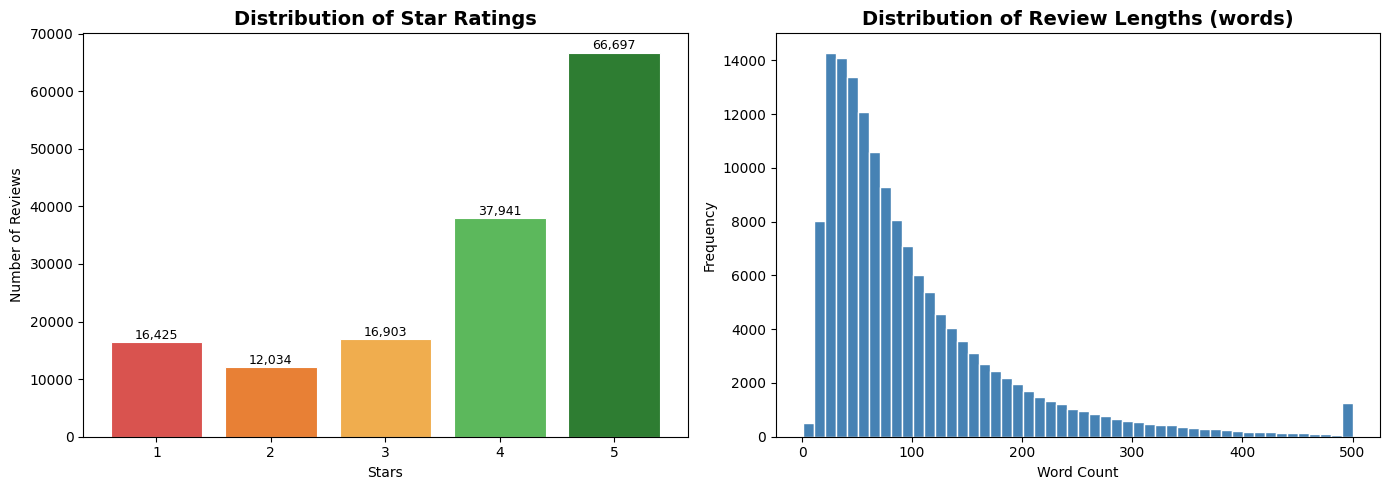


Average review length: 101.3 words


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Star distribution
star_counts = df_raw['stars'].value_counts().sort_index()
colors = ['#d9534f', '#e88035', '#f0ad4e', '#5cb85c', '#2e7d32']
axes[0].bar(star_counts.index, star_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution of Star Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Stars')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])
for i, (star, count) in enumerate(star_counts.items()):
    axes[0].text(star, count + 50, f'{count:,}', ha='center', va='bottom', fontsize=9)

# Review length distribution
df_raw['review_length'] = df_raw['text'].str.split().str.len()
axes[1].hist(df_raw['review_length'].clip(upper=500), bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Review Lengths (words)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAverage review length: {df_raw['review_length'].mean():.1f} words")

---
## 4. Sentiment Labelling

Map star ratings → sentiment categories (as per the paper):

| Stars | Sentiment |
|-------|----------|
| 1–2   | Negative |
| 3     | Neutral  |
| 4–5   | Positive |

Sentiment Distribution:
sentiment
positive    104638
negative     28459
neutral      16903
Name: count, dtype: int64


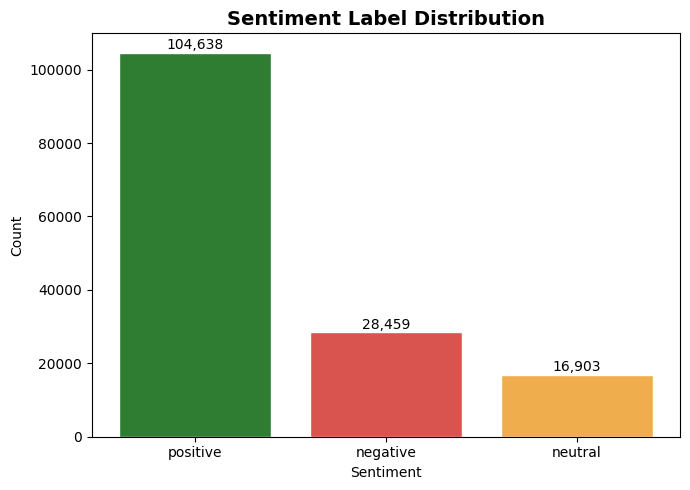

In [6]:
def map_sentiment(stars):
    if stars <= 2:
        return 'negative'
    elif stars == 3:
        return 'neutral'
    else:
        return 'positive'

df_raw['sentiment'] = df_raw['stars'].apply(map_sentiment)

# Sentiment distribution
sentiment_counts = df_raw['sentiment'].value_counts()
print("Sentiment Distribution:")
print(sentiment_counts)

fig, ax = plt.subplots(figsize=(7, 5))
palette = {'positive': '#2e7d32', 'neutral': '#f0ad4e', 'negative': '#d9534f'}
bars = ax.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=[palette[s] for s in sentiment_counts.index],
    edgecolor='white'
)
ax.set_title('Sentiment Label Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Data Preprocessing

Steps: lowercasing → remove noise → tokenize → stopword removal → stemming

In [7]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Full preprocessing pipeline from the paper."""
    # 1. Lowercase
    text = text.lower()
    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # 3. Remove special characters & digits
    text = re.sub(r'[^a-z\s]', '', text)
    # 4. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 5. Tokenize
    tokens = word_tokenize(text)
    # 6. Stopword removal
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

print("🔄 Preprocessing text (this may take a few minutes for large datasets)...")
df_raw['clean_text'] = df_raw['text'].apply(preprocess_text)

# Remove empty reviews after preprocessing
df_raw = df_raw[df_raw['clean_text'].str.strip() != ''].reset_index(drop=True)

print(f"✅ Preprocessing complete! Remaining reviews: {len(df_raw):,}")
print("\nBefore → After example:")
print(f"  BEFORE: {df_raw['text'].iloc[0][:100]}...")
print(f"  AFTER : {df_raw['clean_text'].iloc[0][:100]}...")

🔄 Preprocessing text (this may take a few minutes for large datasets)...
✅ Preprocessing complete! Remaining reviews: 149,994

Before → After example:
  BEFORE: If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We...
  AFTER : decid eat awar go take hour begin end tri multipl time want like locat never bad experi food good ta...


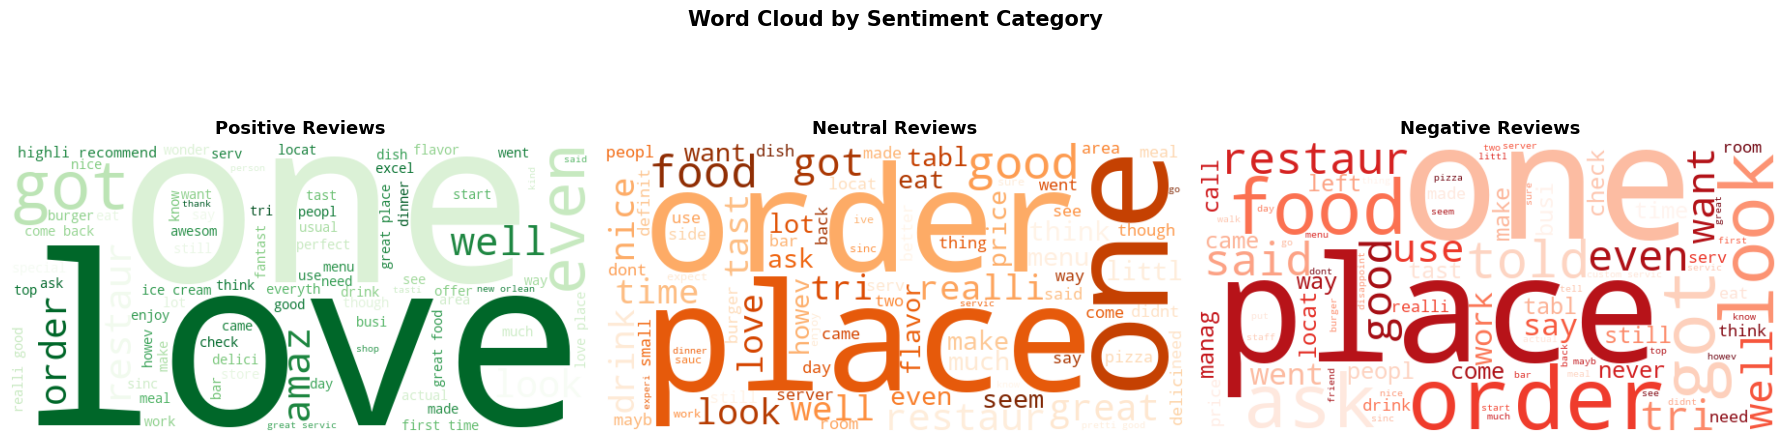

In [8]:
# WordCloud visualization per sentiment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = ['positive', 'neutral', 'negative']
wc_colors = {'positive': 'Greens', 'neutral': 'Oranges', 'negative': 'Reds'}

for ax, sent in zip(axes, sentiments):
    corpus = ' '.join(df_raw[df_raw['sentiment'] == sent]['clean_text'].tolist())
    if corpus.strip():
        wc = WordCloud(
            width=600, height=300,
            background_color='white',
            colormap=wc_colors[sent],
            max_words=80
        ).generate(corpus)
        ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sent.capitalize()} Reviews', fontsize=13, fontweight='bold')

plt.suptitle('Word Cloud by Sentiment Category', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Feature Extraction — TF-IDF

Converts cleaned text into numerical feature vectors.

In [9]:
X = df_raw['clean_text']
y = df_raw['sentiment']

# 80 / 20 train-test split (as specified in the paper)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {len(X_train_raw):,} samples")
print(f"Testing set  : {len(X_test_raw):,} samples")
print(f"\nTrain label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")

Training set : 119,995 samples
Testing set  : 29,999 samples

Train label distribution:
sentiment
positive    83707
negative    22766
neutral     13522
Name: count, dtype: int64

Test label distribution:
sentiment
positive    20927
negative     5692
neutral      3380
Name: count, dtype: int64


In [10]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=10_000,    # Top 10,000 features
    ngram_range=(1, 2),     # Unigrams + bigrams
    sublinear_tf=True,      # Apply log normalization
    min_df=2                # Ignore very rare terms
)

X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

print(f"✅ TF-IDF feature matrix built")
print(f"   Training shape : {X_train.shape}")
print(f"   Testing shape  : {X_test.shape}")
print(f"   Vocabulary size: {len(tfidf.vocabulary_):,}")

✅ TF-IDF feature matrix built
   Training shape : (119995, 10000)
   Testing shape  : (29999, 10000)
   Vocabulary size: 10,000


---
## 7. Model Implementation

### 7.1 Support Vector Machine (SVM)

In [11]:
print("🔧 Training SVM (LinearSVC)...")
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("✅ SVM training complete!")
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred, digits=4))

🔧 Training SVM (LinearSVC)...
✅ SVM training complete!

SVM Classification Report:
              precision    recall  f1-score   support

    negative     0.7952    0.8273    0.8109      5692
     neutral     0.5107    0.2544    0.3397      3380
    positive     0.8977    0.9606    0.9281     20927

    accuracy                         0.8557     29999
   macro avg     0.7345    0.6808    0.6929     29999
weighted avg     0.8346    0.8557    0.8395     29999



### 7.2 Random Forest

In [12]:
print("🔧 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("✅ Random Forest training complete!")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred, digits=4))

🔧 Training Random Forest...
✅ Random Forest training complete!

Random Forest Classification Report:
              precision    recall  f1-score   support

    negative     0.8402    0.6551    0.7362      5692
     neutral     0.6569    0.0198    0.0385      3380
    positive     0.8131    0.9892    0.8925     20927

    accuracy                         0.8166     29999
   macro avg     0.7701    0.5547    0.5557     29999
weighted avg     0.8006    0.8166    0.7666     29999



---
## 8. Evaluation Metrics

In [13]:
def compute_metrics(y_true, y_pred, model_name):
    """Compute all metrics used in the paper."""
    return {
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score' : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

svm_metrics = compute_metrics(y_test, svm_pred, 'SVM (LinearSVC)')
rf_metrics  = compute_metrics(y_test, rf_pred,  'Random Forest')

results_df = pd.DataFrame([svm_metrics, rf_metrics]).set_index('Model')
results_df = results_df.round(4)

print("=" * 55)
print("         PERFORMANCE COMPARISON SUMMARY")
print("=" * 55)
print(results_df.to_string())
print()
winner_metric = results_df['F1 Score'].idxmax()
print(f"🏆 Best F1 Score: {winner_metric} ({results_df.loc[winner_metric, 'F1 Score']:.4f})")

         PERFORMANCE COMPARISON SUMMARY
                 Accuracy  Precision  Recall  F1 Score
Model                                                 
SVM (LinearSVC)    0.8557     0.8346  0.8557    0.8395
Random Forest      0.8166     0.8006  0.8166    0.7666

🏆 Best F1 Score: SVM (LinearSVC) (0.8395)


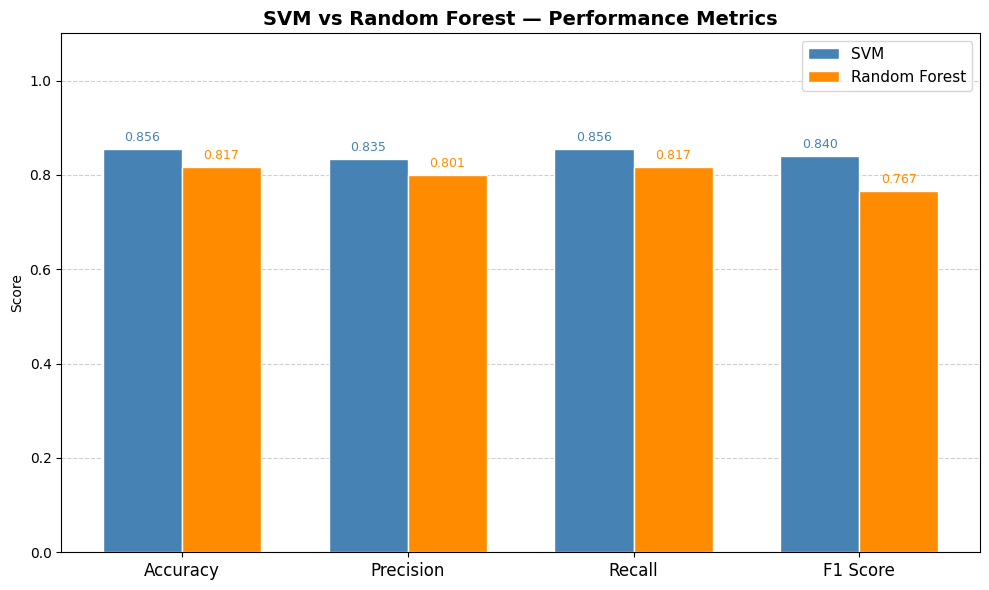

In [14]:
# Grouped bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [svm_metrics[m] for m in metrics], width,
               label='SVM', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, [rf_metrics[m] for m in metrics], width,
               label='Random Forest', color='darkorange', edgecolor='white')

ax.set_title('SVM vs Random Forest — Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='steelblue')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='darkorange')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Confusion Matrices

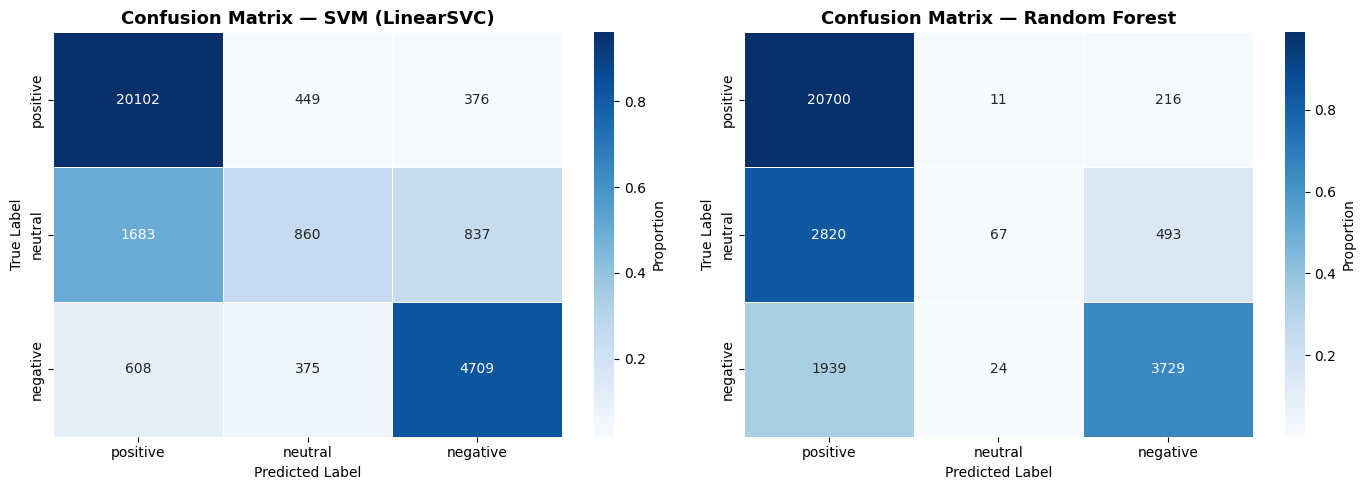

In [15]:
label_order = ['positive', 'neutral', 'negative']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (preds, title) in zip(axes, [
    (svm_pred, 'SVM (LinearSVC)'),
    (rf_pred,  'Random Forest')
]):
    cm = confusion_matrix(y_test, preds, labels=label_order)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalized

    sns.heatmap(
        cm_norm, annot=cm, fmt='d',
        xticklabels=label_order, yticklabels=label_order,
        cmap='Blues', linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Proportion'}
    )
    ax.set_title(f'Confusion Matrix — {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Per-Class Metrics Breakdown

In [16]:
from sklearn.metrics import classification_report

for name, preds in [('SVM', svm_pred), ('Random Forest', rf_pred)]:
    report = classification_report(
        y_test, preds,
        labels=label_order,
        output_dict=True
    )
    report_df = pd.DataFrame(report).T.round(4)
    print(f"\n{'='*50}")
    print(f"  {name} — Per-Class Breakdown")
    print(f"{'='*50}")
    print(report_df.loc[label_order + ['accuracy', 'macro avg', 'weighted avg']].to_string())


  SVM — Per-Class Breakdown
              precision  recall  f1-score     support
positive         0.8977  0.9606    0.9281  20927.0000
neutral          0.5107  0.2544    0.3397   3380.0000
negative         0.7952  0.8273    0.8109   5692.0000
accuracy         0.8557  0.8557    0.8557      0.8557
macro avg        0.7345  0.6808    0.6929  29999.0000
weighted avg     0.8346  0.8557    0.8395  29999.0000

  Random Forest — Per-Class Breakdown
              precision  recall  f1-score     support
positive         0.8131  0.9892    0.8925  20927.0000
neutral          0.6569  0.0198    0.0385   3380.0000
negative         0.8402  0.6551    0.7362   5692.0000
accuracy         0.8166  0.8166    0.8166      0.8166
macro avg        0.7701  0.5547    0.5557  29999.0000
weighted avg     0.8006  0.8166    0.7666  29999.0000


---
## 11. Feature Importance — Top TF-IDF Terms

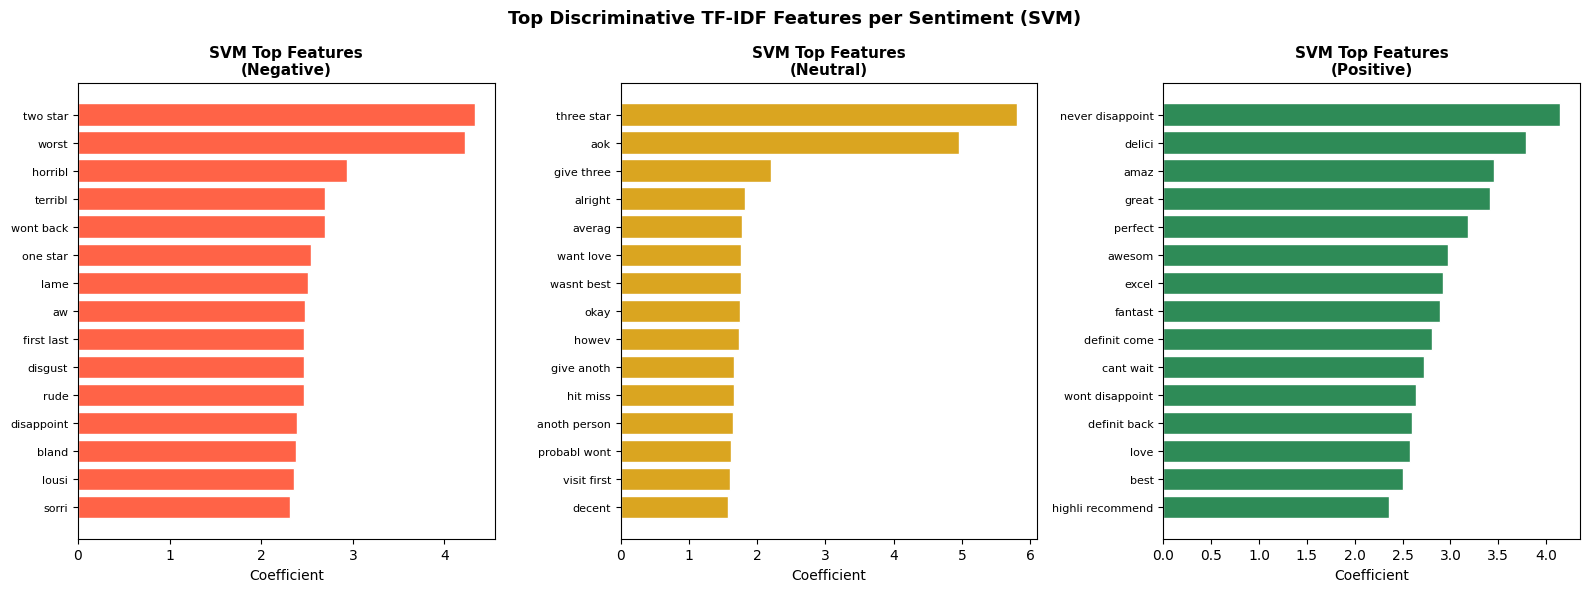

In [17]:
# SVM — top discriminative features per class
feature_names = np.array(tfidf.get_feature_names_out())
classes = svm_model.classes_
top_n = 15

fig, axes = plt.subplots(1, len(classes), figsize=(16, 6))
svm_colors = {'positive': 'seagreen', 'neutral': 'goldenrod', 'negative': 'tomato'}

for ax, cls in zip(axes, classes):
    idx = list(classes).index(cls)
    coef = svm_model.coef_[idx] if len(classes) > 2 else svm_model.coef_[0]
    top_idx = np.argsort(coef)[-top_n:]
    top_features = feature_names[top_idx]
    top_scores   = coef[top_idx]

    ax.barh(top_features, top_scores,
            color=svm_colors.get(cls, 'steelblue'), edgecolor='white')
    ax.set_title(f"SVM Top Features\n({cls.capitalize()})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top Discriminative TF-IDF Features per Sentiment (SVM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

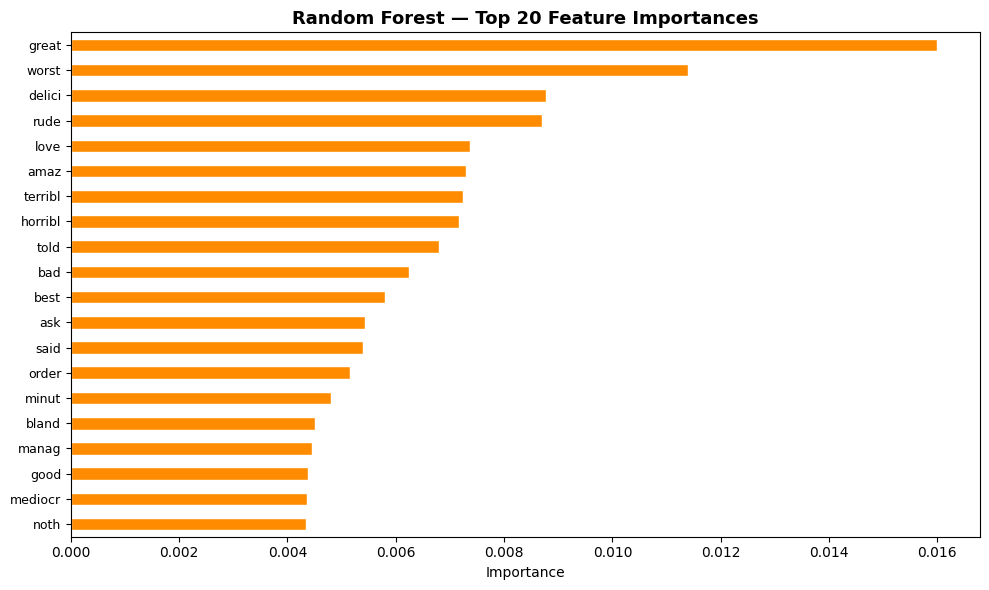

In [18]:
# Random Forest — global feature importances (top 20)
rf_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
rf_importances[::-1].plot(kind='barh', color='darkorange', edgecolor='white', ax=ax)
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Final Summary & Conclusion

In [19]:
print("\n" + "="*60)
print("         FINAL RESULTS SUMMARY")
print("="*60)
print(results_df.to_string())
print("="*60)

best_model  = results_df['F1 Score'].idxmax()
best_acc    = results_df.loc[best_model, 'Accuracy']
best_f1     = results_df.loc[best_model, 'F1 Score']

print(f"""
CONCLUSION
──────────
• Best performing model : {best_model}
• Accuracy              : {best_acc:.4f} ({best_acc*100:.2f}%)
• Weighted F1 Score     : {best_f1:.4f}

Both SVM and Random Forest were evaluated on the Yelp restaurant
review dataset. TF-IDF feature extraction with an 80/20 train/test
split was used throughout.

This analysis demonstrates that machine learning can effectively
classify customer sentiment from online reviews, providing restaurant
managers with actionable insights into service quality and
customer satisfaction.
""")


         FINAL RESULTS SUMMARY
                 Accuracy  Precision  Recall  F1 Score
Model                                                 
SVM (LinearSVC)    0.8557     0.8346  0.8557    0.8395
Random Forest      0.8166     0.8006  0.8166    0.7666

CONCLUSION
──────────
• Best performing model : SVM (LinearSVC)
• Accuracy              : 0.8557 (85.57%)
• Weighted F1 Score     : 0.8395

Both SVM and Random Forest were evaluated on the Yelp restaurant
review dataset. TF-IDF feature extraction with an 80/20 train/test
split was used throughout.

This analysis demonstrates that machine learning can effectively
classify customer sentiment from online reviews, providing restaurant
managers with actionable insights into service quality and
customer satisfaction.

